# Image and Video Processing Lab 8

### Import Libraries

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import exposure

In [18]:
def show(title, img):
    plt.figure(figsize=(5,5))
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')

### Load Image

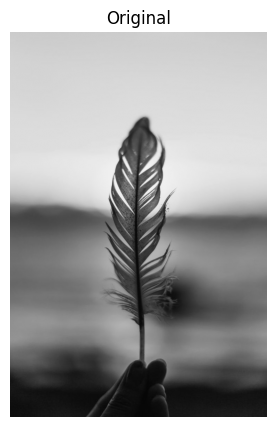

In [19]:
img = cv2.imread('feather.jpg', cv2.IMREAD_GRAYSCALE)
show("Original", img)

### Experiment #1: Edge Detection

#### Sobel Filter

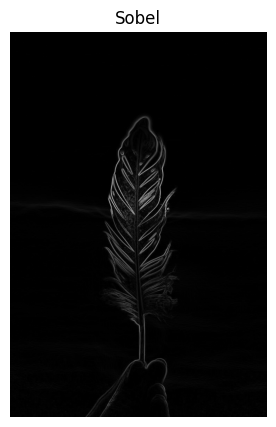

In [20]:
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
sobel = np.sqrt(sobelx**2 + sobely**2)

show("Sobel", sobel)

#### Prewitt

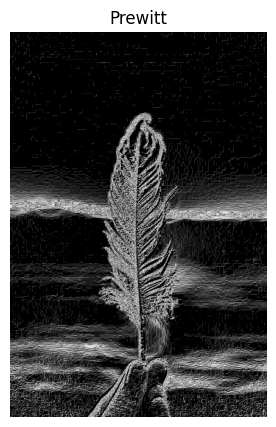

In [21]:
kernelx = np.array([[1,0,-1],[1,0,-1],[1,0,-1]])
kernely = np.array([[1,1,1],[0,0,0],[-1,-1,-1]])

prewittx = cv2.filter2D(img, -1, kernelx)
prewitty = cv2.filter2D(img, -1, kernely)
prewitt = np.sqrt(prewittx**2 + prewitty**2)

show("Prewitt", prewitt)

#### Roberts

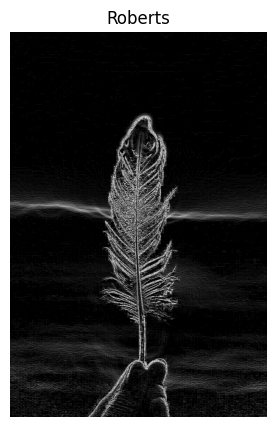

In [22]:
kernelx = np.array([[1,0],[0,-1]])
kernely = np.array([[0,1],[-1,0]])

robertsx = cv2.filter2D(img, -1, kernelx)
robertsy = cv2.filter2D(img, -1, kernely)
roberts = np.sqrt(robertsx**2 + robertsy**2)

show("Roberts", roberts)

#### Scharr

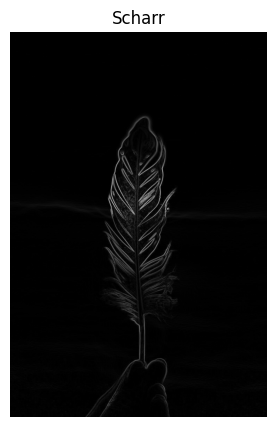

In [23]:
scharrx = cv2.Scharr(img, cv2.CV_64F, 1, 0)
scharry = cv2.Scharr(img, cv2.CV_64F, 0, 1)
scharr = np.sqrt(scharrx**2 + scharry**2)

show("Scharr", scharr)

#### DoG (Difference of Gaussian)

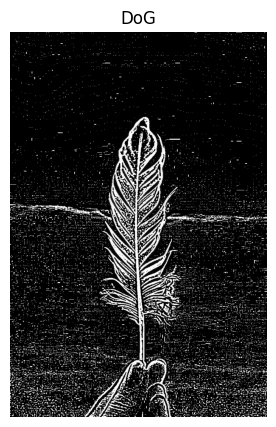

In [24]:
blur1 = cv2.GaussianBlur(img, (5,5), 1)
blur2 = cv2.GaussianBlur(img, (9,9), 2)

dog = blur1 - blur2

show("DoG", dog)

#### LoG (Laplacian of Gaussian)

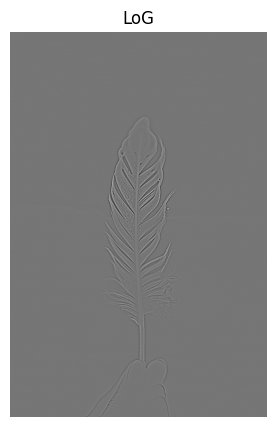

In [25]:
blur = cv2.GaussianBlur(img, (5,5), 0)
log = cv2.Laplacian(blur, cv2.CV_64F)

show("LoG", log)

#### Canny Edge Detection

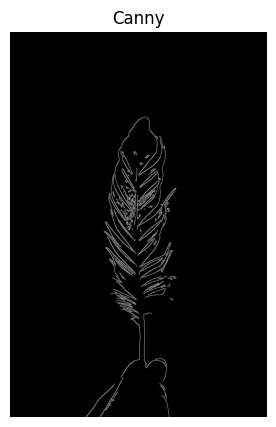

In [26]:
canny = cv2.Canny(img, 100, 200)

show("Canny", canny)

### Experiment #2: Line Detection

#### Hough Transform

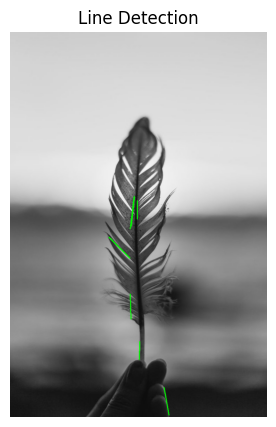

In [27]:
edges = cv2.Canny(img, 100, 200)
lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=100, minLineLength=50, maxLineGap=10)

img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(img_color, (x1,y1), (x2,y2), (0,255,0), 2)

show("Line Detection", img_color)

### Experiment #3: HOG Visualization

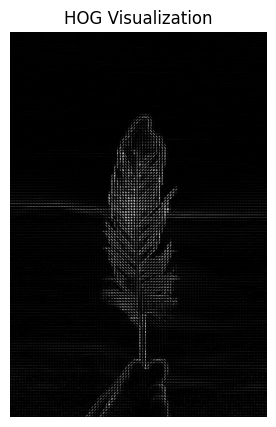

In [28]:
features, hog_image = hog(img,
                          orientations=9,
                          pixels_per_cell=(8,8),
                          cells_per_block=(2,2),
                          visualize=True)

hog_image = exposure.rescale_intensity(hog_image, in_range=(0,10))

show("HOG Visualization", hog_image)

### Experiment #4: People Detection Using HoG

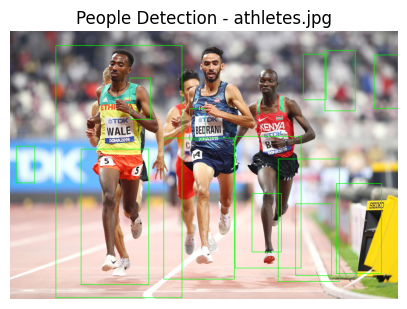

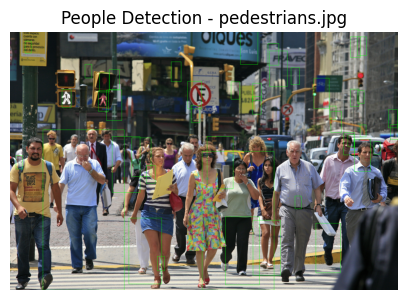

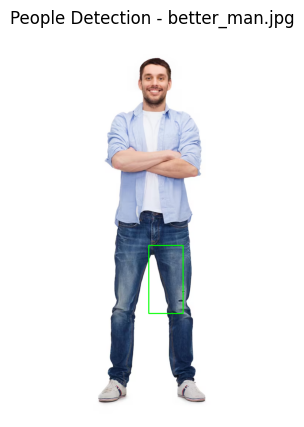

In [51]:
hog = cv2.HOGDescriptor()
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())

image_files = ['athletes.jpg', 'pedestrians.jpg', 'better_man.jpg']  # add as many as you want

for filename in image_files:
    img_color = cv2.imread(filename, cv2.IMREAD_COLOR)

    if img_color is None:
        print(f"Could not load {filename}, skipping.")
        continue

    gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

    boxes, weights = hog.detectMultiScale(
        gray,
        winStride=(4, 4),
        padding=(8, 8),
        scale=1.05
    )

    output = img_color.copy()
    for (x, y, w, h) in boxes:
        cv2.rectangle(output, (x, y), (x + w, y + h), (0, 255, 0), 2)

    show(f"People Detection - {filename}", cv2.cvtColor(output, cv2.COLOR_BGR2RGB))

- Different edge detectors respond to different gradient characteristics.
- Canny provides clean and well-defined edges.
- Hough Transform effectively detects lines.
- HOG captures gradient structure and is useful for object detection.